## Importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\PANEL_SENTIMENT_WINDOWS_2020_2022.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Tickers : {df['Ticker'].unique()}")
print(f"Période : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Jours par ticker :")
print(df.groupby('Ticker')['Date'].nunique())

Shape : (2740, 76)
Tickers : ['AAPL' 'AMZN' 'META' 'NVDA' 'TSLA']
Période : 2020-01-02 → 2022-03-04
Jours par ticker :
Ticker
AAPL    548
AMZN    548
META    548
NVDA    548
TSLA    548
Name: Date, dtype: int64


## Statistique

In [3]:
# Variables sentiment par fenêtre
sent_vars = {
    'night_full': ['mu_night_full', 'sd_night_full', 'n_night_full', 'nlog_night_full', 'nabn_night_full'],
    'pre':        ['mu_pre', 'sd_pre', 'n_pre'],
    'open30':     ['mu_open30', 'sd_open30', 'n_open30'],
    'mkt':        ['mu_mkt', 'sd_mkt', 'n_mkt'],
    'post':       ['mu_post', 'sd_post', 'n_post'],
}

# Cibles
targets = ['gap', 'ret_oc', 'ret_cc', 'y_gap', 'y_oc', 'y_cc']

# Stats par ticker
all_vars = [v for vs in sent_vars.values() for v in vs] + targets
stats_df = df.groupby('Ticker')[all_vars].describe().T
stats_df.to_csv(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_stats_descriptives.csv")
print("Statistiques sauvegardées dans EDA_stats_descriptives.csv")
stats_df.loc[[('gap', 'mean'), ('gap', 'std'), ('ret_oc', 'mean'), ('ret_oc', 'std'),
              ('mu_night_full', 'mean'), ('mu_night_full', 'std'),
              ('n_night_full', 'mean'), ('n_night_full', 'std')]]

Statistiques sauvegardées dans EDA_stats_descriptives.csv


Ticker                    AAPL        AMZN        META        NVDA  \
gap           mean    0.000658    0.001244   -0.000251    0.002190   
              std     0.015395    0.014171    0.018723    0.019257   
ret_oc        mean    0.001065   -0.000171    0.000556    0.000837   
              std     0.017039    0.016870    0.018269    0.026738   
mu_night_full mean    0.093384    0.115720    0.111634    0.160010   
              std     0.042353    0.049469    0.068034    0.078729   
n_night_full  mean  703.538321  318.706204  198.476277  169.755474   
              std   642.054834  534.474431  603.217038  345.461716   

Ticker                     TSLA  
gap           mean     0.004020  
              std      0.029777  
ret_oc        mean     0.001288  
              std      0.036268  
mu_night_full mean     0.044442  
              std      0.032299  
n_night_full  mean  1474.425182  
              std   1449.826676

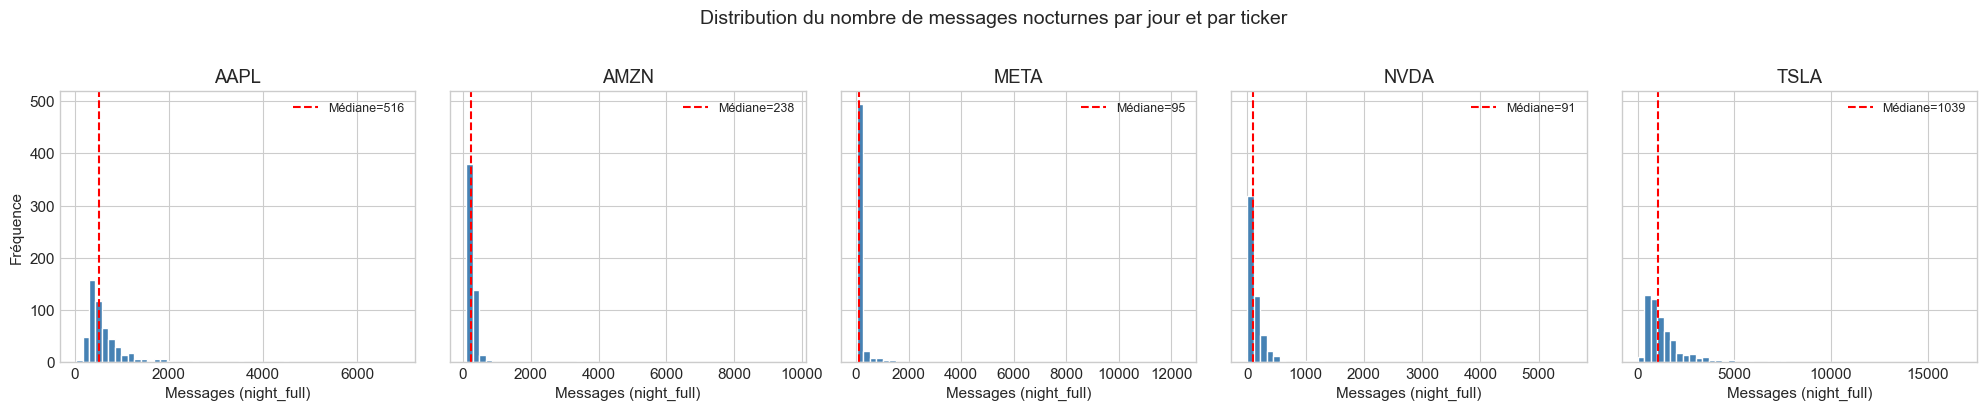

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, ticker in enumerate(df['Ticker'].unique()):
    sub = df[df['Ticker'] == ticker]
    axes[i].hist(sub['n_night_full'].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{ticker}')
    axes[i].set_xlabel('Messages (night_full)')
    axes[i].axvline(sub['n_night_full'].median(), color='red', linestyle='--', label=f'Médiane={sub["n_night_full"].median():.0f}')
    axes[i].legend(fontsize=9)
axes[0].set_ylabel('Fréquence')
plt.suptitle('Distribution du nombre de messages nocturnes par jour et par ticker', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig1_density.png", dpi=150, bbox_inches='tight')
plt.show()

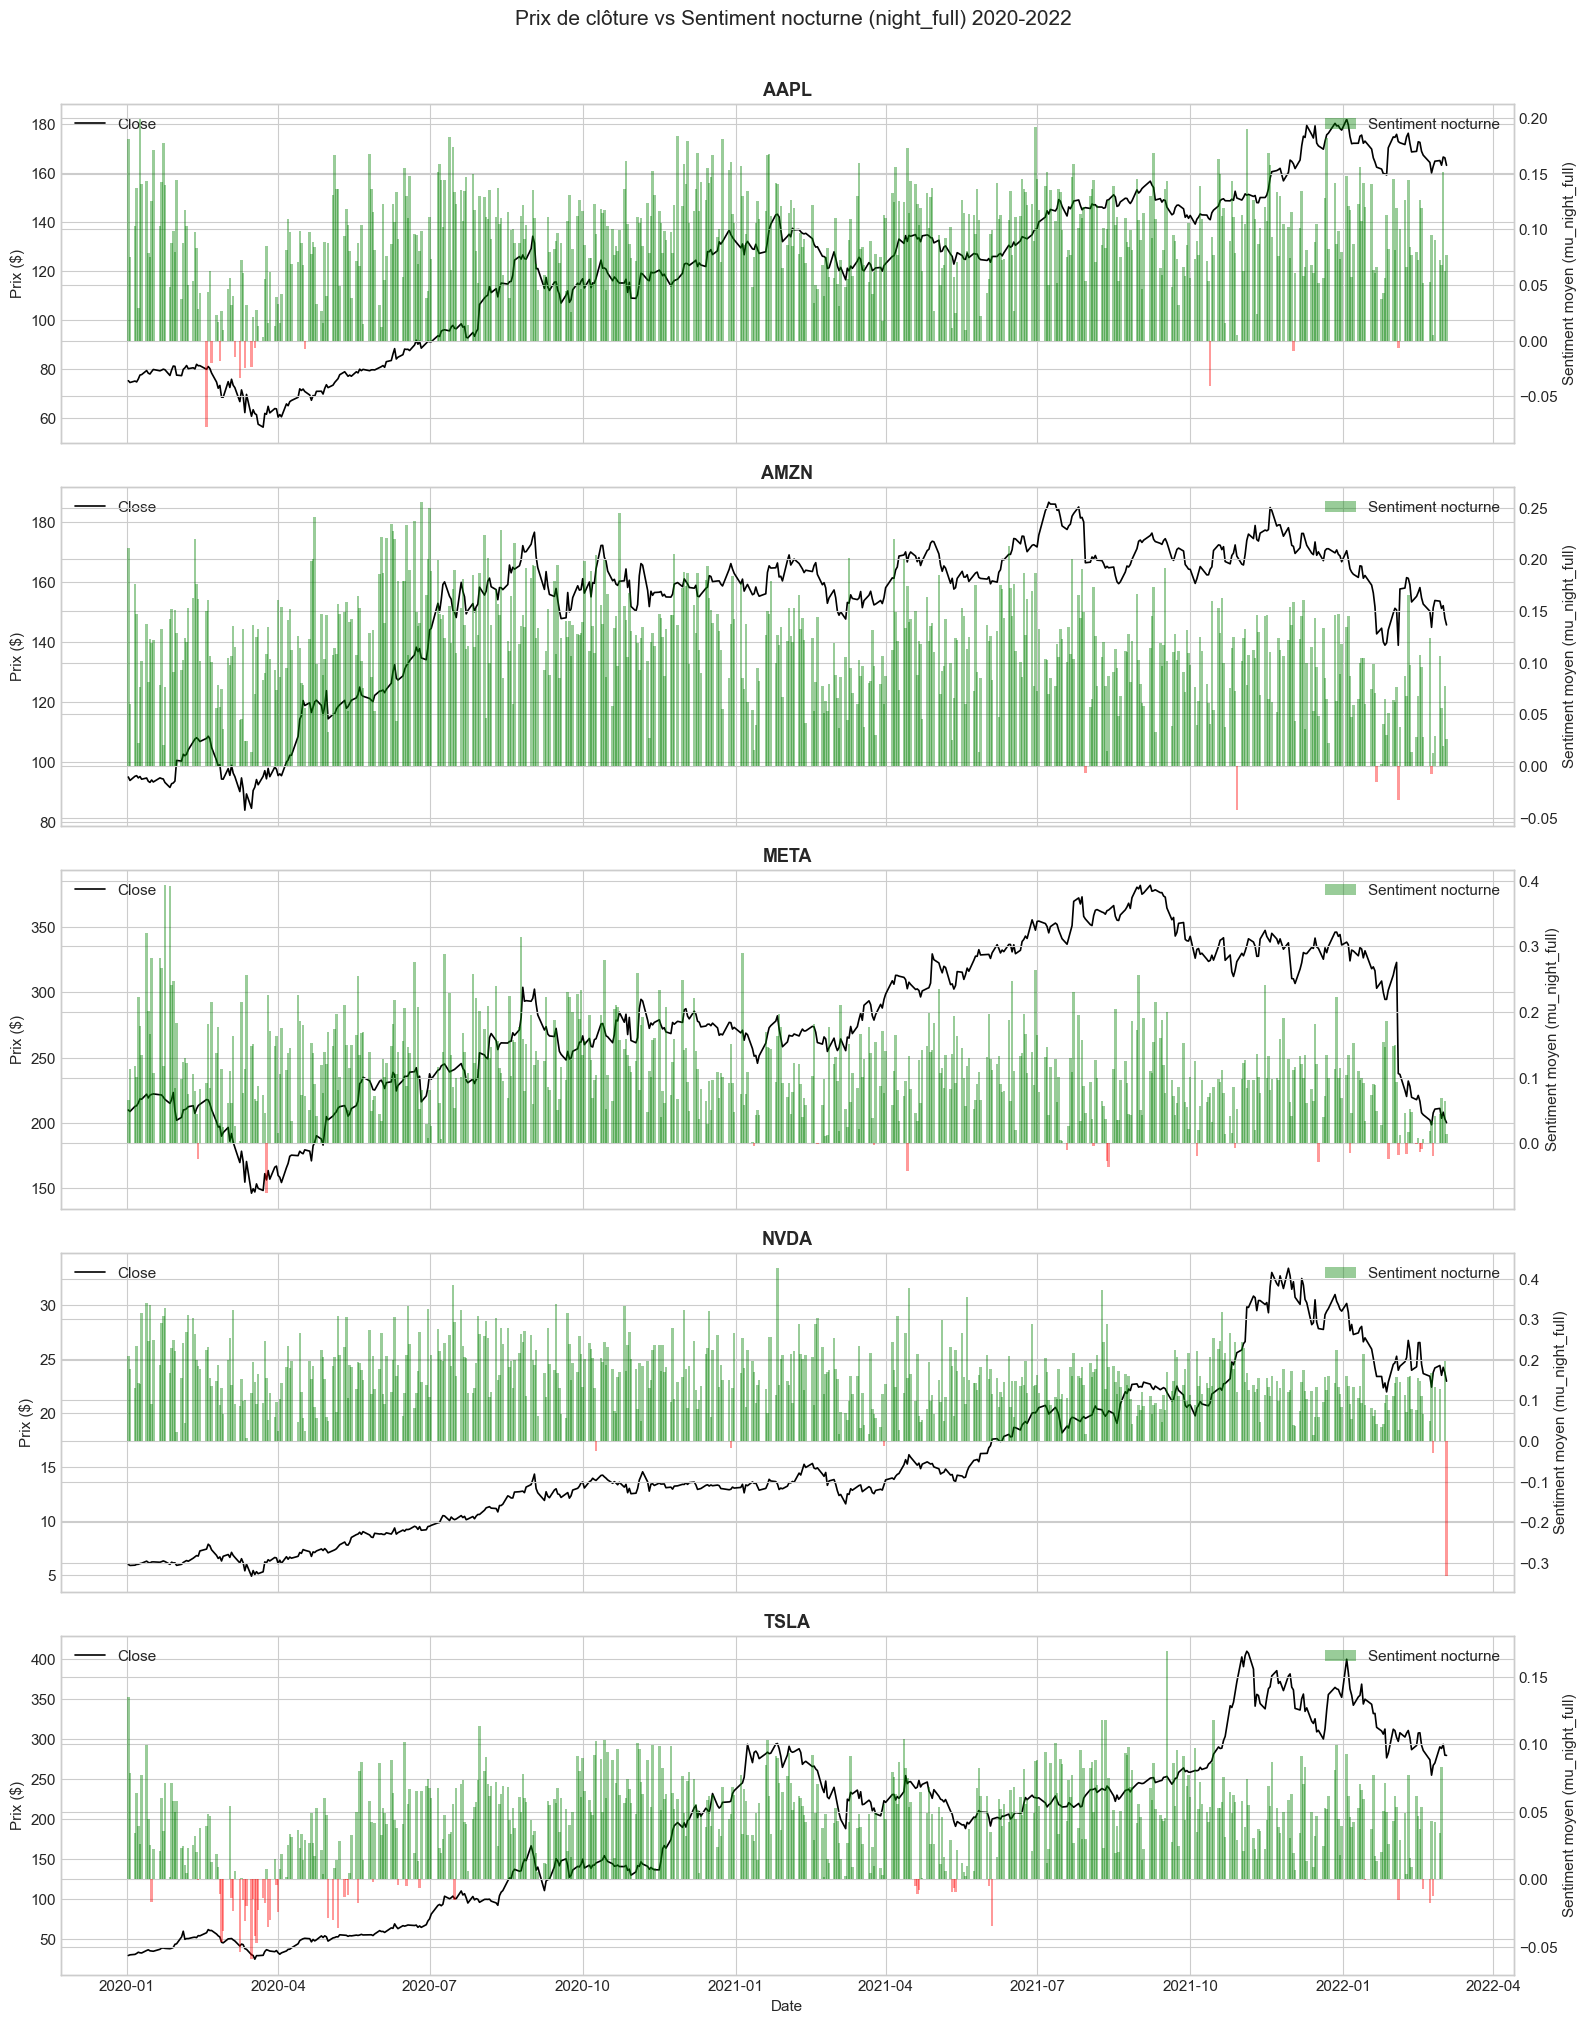

In [5]:
tickers = df['Ticker'].unique()
fig, axes = plt.subplots(len(tickers), 1, figsize=(16, 4*len(tickers)), sharex=True)

for i, ticker in enumerate(tickers):
    sub = df[df['Ticker'] == ticker].sort_values('Date')
    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(sub['Date'], sub['Close'], color='black', linewidth=1.2, label='Close')
    ax2.bar(sub['Date'], sub['mu_night_full'], color=np.where(sub['mu_night_full'] >= 0, 'green', 'red'),
            alpha=0.4, width=1.5, label='Sentiment nocturne')

    ax1.set_ylabel('Prix ($)', fontsize=11)
    ax2.set_ylabel('Sentiment moyen (mu_night_full)', fontsize=11)
    ax1.set_title(f'{ticker}', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.suptitle('Prix de clôture vs Sentiment nocturne (night_full) 2020-2022', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig2_price_vs_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
windows = ['mu_overnight', 'mu_pre', 'mu_night_full', 'mu_open30', 'mu_mkt', 'mu_post']
targets_corr = ['gap', 'ret_oc', 'ret_cc']

results = []
for target in targets_corr:
    for window in windows:
        valid = df[[window, target]].dropna()
        rho, pval = stats.pearsonr(valid[window], valid[target])
        results.append({
            'Cible': target,
            'Fenêtre': window,
            'rho': round(rho, 4),
            'p_value': f'{pval:.2e}',
            'n': len(valid)
        })

corr_all = pd.DataFrame(results)
print(corr_all.pivot(index='Fenêtre', columns='Cible', values='rho').round(4))
corr_all.to_csv(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_correlations_all_windows.csv", index=False)

Cible             gap  ret_cc  ret_oc
Fenêtre                              
mu_mkt         0.0672  0.2025  0.2081
mu_night_full  0.1651  0.0986 -0.0100
mu_open30      0.0623  0.1186  0.1021
mu_overnight   0.1010  0.0426 -0.0296
mu_post        0.0626  0.1703  0.1699
mu_pre         0.1816  0.1265  0.0128


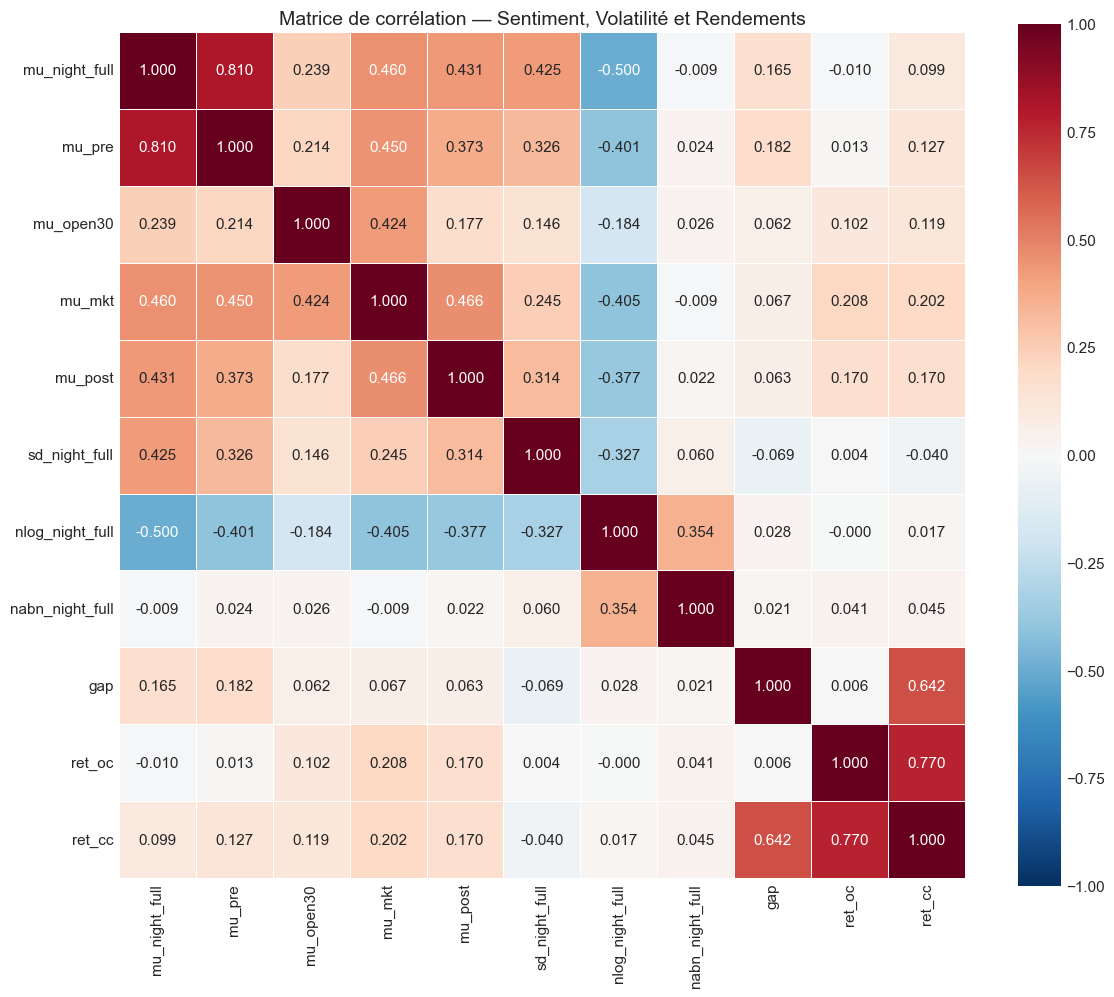

In [9]:
import seaborn as sns

features_heatmap = ['mu_night_full', 'mu_pre', 'mu_open30', 'mu_mkt', 'mu_post',
                     'sd_night_full', 'nlog_night_full', 'nabn_night_full',
                     'gap', 'ret_oc', 'ret_cc']

corr_matrix = df[features_heatmap].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélation — Sentiment, Volatilité et Rendements', fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig3_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
n_quintiles = 5
results_q = []

for ticker in df['Ticker'].unique():
    sub = df[df['Ticker'] == ticker].copy()
    sub['quintile'] = pd.qcut(sub['mu_night_full'], q=n_quintiles, labels=['Q1\nTrès négatif', 'Q2', 'Q3\nNeutre', 'Q4', 'Q5\nTrès positif'])

    for q in sub['quintile'].unique():
        grp = sub[sub['quintile'] == q]
        results_q.append({
            'Ticker': ticker,
            'Quintile': q,
            'n': len(grp),
            'Gap moyen (%)': round(grp['gap'].mean() * 100, 3),
            '% Gap positif': round((grp['y_gap'] == 1).mean() * 100, 1),
            'Séance moyenne (%)': round(grp['ret_oc'].mean() * 100, 3),
            '% Séance positive': round((grp['y_oc'] == 1).mean() * 100, 1),
            'Close-Close moyen (%)': round(grp['ret_cc'].mean() * 100, 3),
        })

quintile_df = pd.DataFrame(results_q)
print("=== PAR TICKER ===")
print(quintile_df.to_string(index=False))

# Pooled (tous tickers confondus)
df_pooled = df.copy()
df_pooled['quintile'] = pd.qcut(df_pooled['mu_night_full'], q=n_quintiles, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
pooled = df_pooled.groupby('quintile').agg(
    n=('gap', 'size'),
    gap_moyen=('gap', 'mean'),
    pct_gap_pos=('y_gap', 'mean'),
    seance_moyenne=('ret_oc', 'mean'),
    pct_seance_pos=('y_oc', 'mean'),
    cc_moyen=('ret_cc', 'mean')
).round(4)
pooled['gap_moyen'] = (pooled['gap_moyen'] * 100).round(3)
pooled['seance_moyenne'] = (pooled['seance_moyenne'] * 100).round(3)
pooled['cc_moyen'] = (pooled['cc_moyen'] * 100).round(3)
pooled['pct_gap_pos'] = (pooled['pct_gap_pos'] * 100).round(1)
pooled['pct_seance_pos'] = (pooled['pct_seance_pos'] * 100).round(1)

print("\n=== POOLED (tous tickers) ===")
print(pooled)

=== PAR TICKER ===
Ticker         Quintile   n  Gap moyen (%)  % Gap positif  Séance moyenne (%)  % Séance positive  Close-Close moyen (%)
  AAPL Q5\nTrès positif 110          0.468           72.7               0.223               56.4                  0.695
  AAPL               Q2 109         -0.059           50.5               0.072               53.2                  0.021
  AAPL       Q3\nNeutre 110          0.362           64.5              -0.082               47.3                  0.281
  AAPL Q1\nTrès négatif 110         -0.805           31.8               0.577               61.8                 -0.234
  AAPL               Q4 109          0.365           64.2              -0.260               45.9                  0.100
  AMZN Q5\nTrès positif 110          0.426           71.8              -0.042               44.5                  0.382
  AMZN Q1\nTrès négatif 110         -0.529           40.0               0.144               54.5                 -0.389
  AMZN               

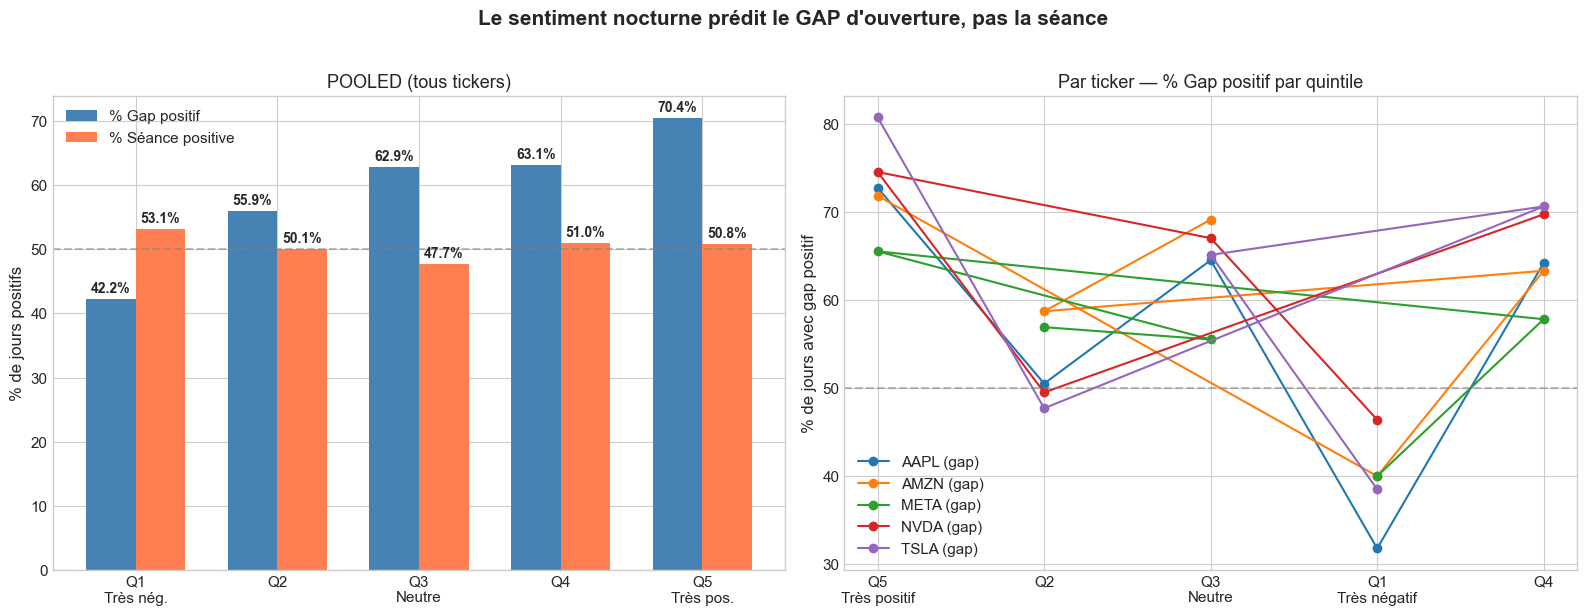

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe pooled
ax1 = axes[0]
x = range(n_quintiles)
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], pooled['pct_gap_pos'], width, label='% Gap positif', color='steelblue')
bars2 = ax1.bar([i + width/2 for i in x], pooled['pct_seance_pos'], width, label='% Séance positive', color='coral')
ax1.set_xticks(list(x))
ax1.set_xticklabels(['Q1\nTrès nég.', 'Q2', 'Q3\nNeutre', 'Q4', 'Q5\nTrès pos.'])
ax1.set_ylabel('% de jours positifs', fontsize=12)
ax1.set_title('POOLED (tous tickers)', fontsize=13)
ax1.legend()
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5)

# Ajouter les valeurs sur les barres
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

# Graphe par ticker
ax2 = axes[1]
for ticker in df['Ticker'].unique():
    sub_t = quintile_df[(quintile_df['Ticker'] == ticker) & (quintile_df['Quintile'].notna())]
    ax2.plot(sub_t['Quintile'], sub_t['% Gap positif'], marker='o', label=f'{ticker} (gap)')
ax2.set_ylabel('% de jours avec gap positif', fontsize=12)
ax2.set_title('Par ticker — % Gap positif par quintile', fontsize=13)
ax2.legend()
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Le sentiment nocturne prédit le GAP d\'ouverture, pas la séance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig4_quintiles.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from scipy.stats import spearmanr

# Test de Spearman entre quintile et % gap positif
quintile_numeric = [1, 2, 3, 4, 5]
pooled_vals = pooled['pct_gap_pos'].values

rho_s, p_s = spearmanr(quintile_numeric, pooled_vals)
print(f"Spearman (quintile vs % gap positif) : rho = {rho_s:.3f}, p = {p_s:.4e}")

# Par ticker
print("\nPar ticker :")
for ticker in df['Ticker'].unique():
    sub_t = quintile_df[(quintile_df['Ticker'] == ticker) & (quintile_df['Quintile'].notna())]
    if len(sub_t) == 5:
        rho_t, p_t = spearmanr([1, 2, 3, 4, 5], sub_t['% Gap positif'].values)
        print(f"  {ticker}: rho = {rho_t:.3f}, p = {p_t:.4e}")
    else:
        print(f"  {ticker}: skipping (quintiles invalides)")

Spearman (quintile vs % gap positif) : rho = 1.000, p = 1.4043e-24

Par ticker :
  AAPL: rho = -0.500, p = 3.9100e-01
  AMZN: rho = -0.100, p = 8.7289e-01
  META: rho = -0.200, p = 7.4706e-01
  NVDA: rho = -0.500, p = 3.9100e-01
  TSLA: rho = -0.700, p = 1.8812e-01


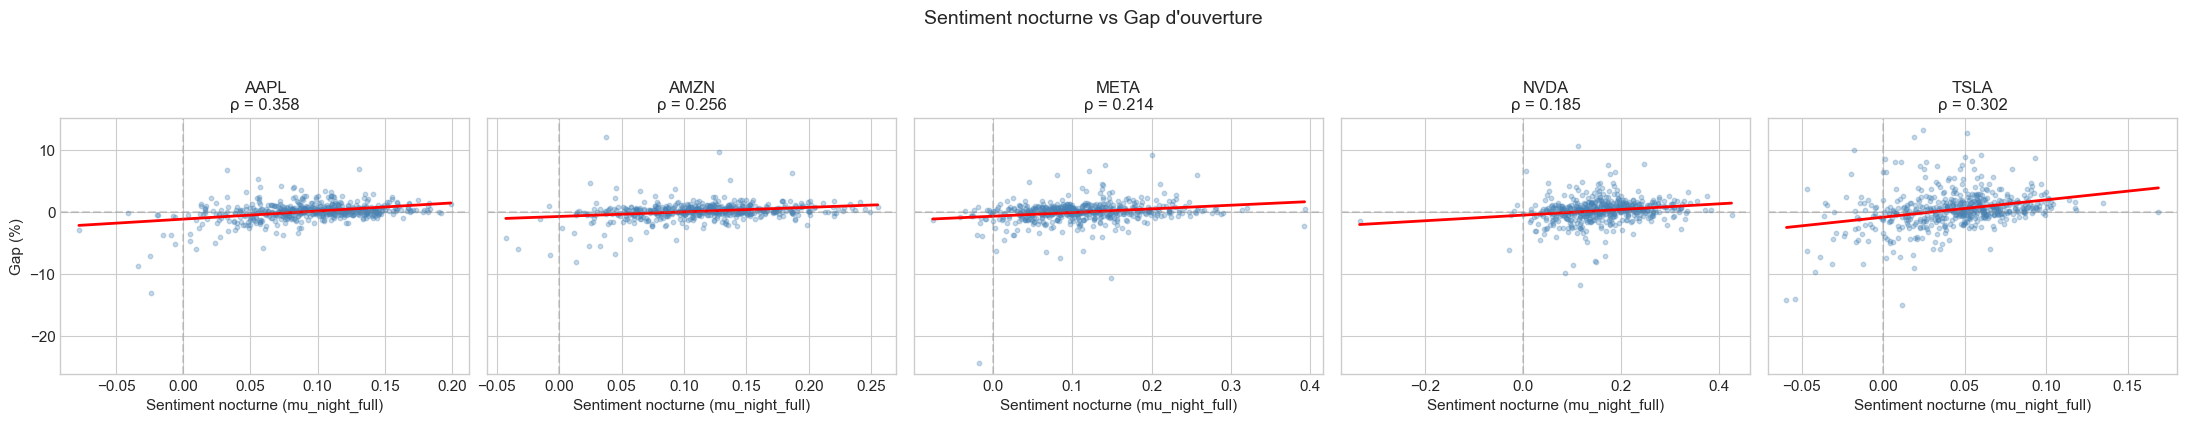

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for i, ticker in enumerate(df['Ticker'].unique()):
    sub = df[df['Ticker'] == ticker][['mu_night_full', 'gap']].dropna()
    axes[i].scatter(sub['mu_night_full'], sub['gap'] * 100, alpha=0.3, s=10, color='steelblue')
    z = np.polyfit(sub['mu_night_full'], sub['gap'] * 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['mu_night_full'].min(), sub['mu_night_full'].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2)
    rho = sub['mu_night_full'].corr(sub['gap'])
    axes[i].set_title(f'{ticker}\nρ = {rho:.3f}', fontsize=12)
    axes[i].set_xlabel('Sentiment nocturne (mu_night_full)')
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[i].axvline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Gap (%)')
plt.suptitle('Sentiment nocturne vs Gap d\'ouverture', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig5_scatter_gap.png", dpi=150, bbox_inches='tight')
plt.show()

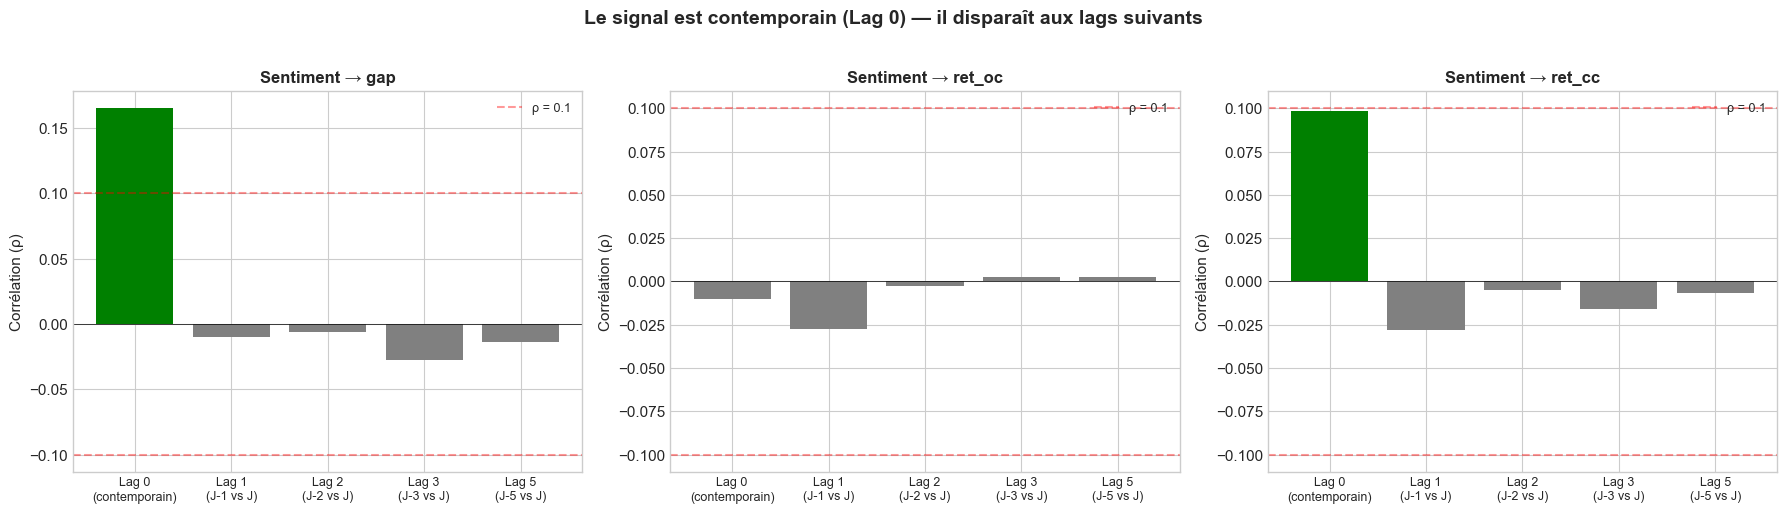

In [14]:
df_lag = df.copy()
df_lag['mu_night_full_lag1'] = df_lag.groupby('Ticker')['mu_night_full'].shift(1)
df_lag['mu_night_full_lag2'] = df_lag.groupby('Ticker')['mu_night_full'].shift(2)
df_lag['mu_night_full_lag3'] = df_lag.groupby('Ticker')['mu_night_full'].shift(3)
df_lag['mu_night_full_lag5'] = df_lag.groupby('Ticker')['mu_night_full'].shift(5)

lag_vars = ['mu_night_full', 'mu_night_full_lag1', 'mu_night_full_lag2',
            'mu_night_full_lag3', 'mu_night_full_lag5']
lag_labels = ['Lag 0\n(contemporain)', 'Lag 1\n(J-1 vs J)', 'Lag 2\n(J-2 vs J)',
              'Lag 3\n(J-3 vs J)', 'Lag 5\n(J-5 vs J)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, target in enumerate(['gap', 'ret_oc', 'ret_cc']):
    rhos = []
    for var in lag_vars:
        valid = df_lag[[var, target]].dropna()
        rho, _ = stats.pearsonr(valid[var], valid[target])
        rhos.append(rho)

    axes[idx].bar(range(len(lag_labels)), rhos, color=['green' if abs(r) > 0.05 else 'gray' for r in rhos])
    axes[idx].set_xticks(range(len(lag_labels)))
    axes[idx].set_xticklabels(lag_labels, fontsize=9)
    axes[idx].set_ylabel('Corrélation (ρ)')
    axes[idx].set_title(f'Sentiment → {target}', fontsize=12, fontweight='bold')
    axes[idx].axhline(0, color='black', linewidth=0.5)
    axes[idx].axhline(0.1, color='red', linestyle='--', alpha=0.4, label='ρ = 0.1')
    axes[idx].axhline(-0.1, color='red', linestyle='--', alpha=0.4)
    axes[idx].legend(fontsize=9)

plt.suptitle('Le signal est contemporain (Lag 0) — il disparaît aux lags suivants', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig6_lag_effect.png", dpi=150, bbox_inches='tight')
plt.show()

Ticker                                  Régime   N  ρ(gap)  ρ(séance)  Gap moyen (%)
  AAPL             COVID Crash\n(jan-mar 2020)  56   0.459     -0.019          -0.71
  AAPL Rallye Liquidity\n(avr 2020 - jan 2021) 215   0.263     -0.186           0.33
  AAPL                 Meme Stocks\n(jan 2021)  20   0.495     -0.286          -0.10
  AAPL                     Bear Market\n(2022) 257   0.303      0.014           0.02
  AMZN             COVID Crash\n(jan-mar 2020)  56   0.325     -0.043          -0.09
  AMZN Rallye Liquidity\n(avr 2020 - jan 2021) 215   0.266     -0.003           0.27
  AMZN                 Meme Stocks\n(jan 2021)  20   0.490     -0.213          -0.08
  AMZN                     Bear Market\n(2022) 257   0.212     -0.014           0.07
  META             COVID Crash\n(jan-mar 2020)  56   0.272     -0.141          -0.65
  META Rallye Liquidity\n(avr 2020 - jan 2021) 215   0.204      0.059           0.23
  META                 Meme Stocks\n(jan 2021)  20   0.312      0

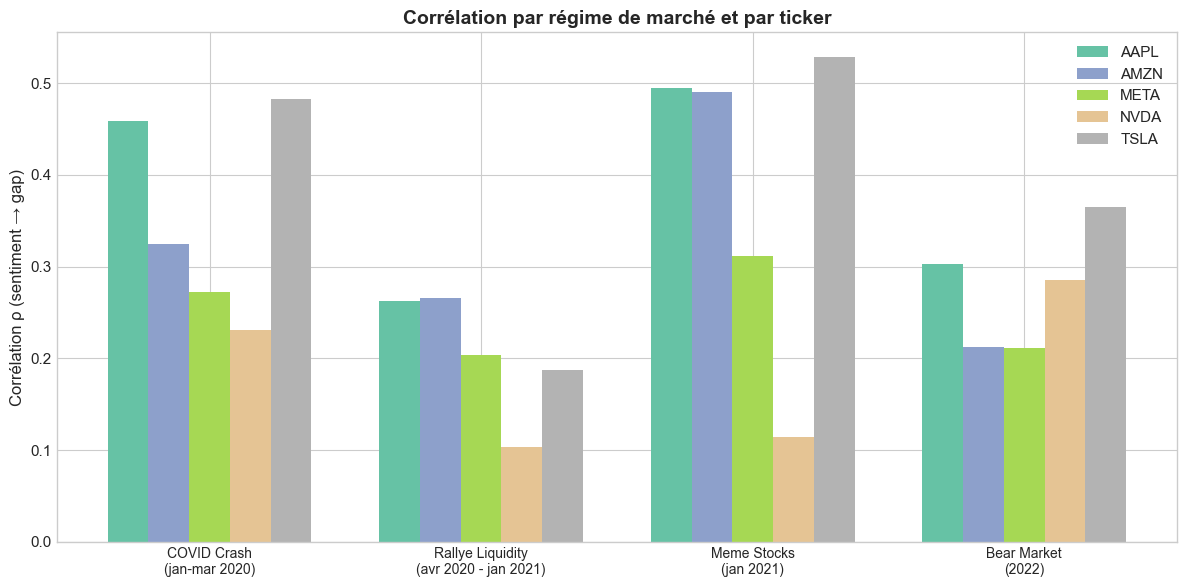

In [15]:
def get_regime(date):
    if date <= pd.Timestamp('2020-03-23'):
        return 'COVID Crash\n(jan-mar 2020)'
    elif date <= pd.Timestamp('2021-01-28'):
        return 'Rallye Liquidity\n(avr 2020 - jan 2021)'
    elif date <= pd.Timestamp('2021-02-28'):
        return 'Meme Stocks\n(jan 2021)'
    else:
        return 'Bear Market\n(2022)'

df['regime'] = df['Date'].apply(get_regime)

regime_results = []
for ticker in df['Ticker'].unique():
    sub = df[df['Ticker'] == ticker]
    for regime in sub['regime'].unique():
        grp = sub[sub['regime'] == regime]
        rho_gap = grp['mu_night_full'].corr(grp['gap'])
        rho_oc = grp['mu_night_full'].corr(grp['ret_oc'])
        regime_results.append({
            'Ticker': ticker,
            'Régime': regime,
            'N': len(grp),
            'ρ(gap)': round(rho_gap, 3),
            'ρ(séance)': round(rho_oc, 3),
            'Gap moyen (%)': round(grp['gap'].mean() * 100, 2),
        })

regime_df = pd.DataFrame(regime_results)
print(regime_df.to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
regime_order = ['COVID Crash\n(jan-mar 2020)', 'Rallye Liquidity\n(avr 2020 - jan 2021)',
                'Meme Stocks\n(jan 2021)', 'Bear Market\n(2022)']
x = np.arange(len(regime_order))
width = 0.15
colors = plt.cm.Set2(np.linspace(0, 1, 5))

for i, ticker in enumerate(df['Ticker'].unique()):
    sub_t = regime_df[regime_df['Ticker'] == ticker].set_index('Régime').reindex(regime_order)
    ax.bar(x + i * width, sub_t['ρ(gap)'].values, width, label=ticker, color=colors[i])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(regime_order, fontsize=10)
ax.set_ylabel('Corrélation ρ (sentiment → gap)', fontsize=12)
ax.set_title('Corrélation par régime de marché et par ticker', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig8_regimes.png", dpi=150, bbox_inches='tight')
plt.show()

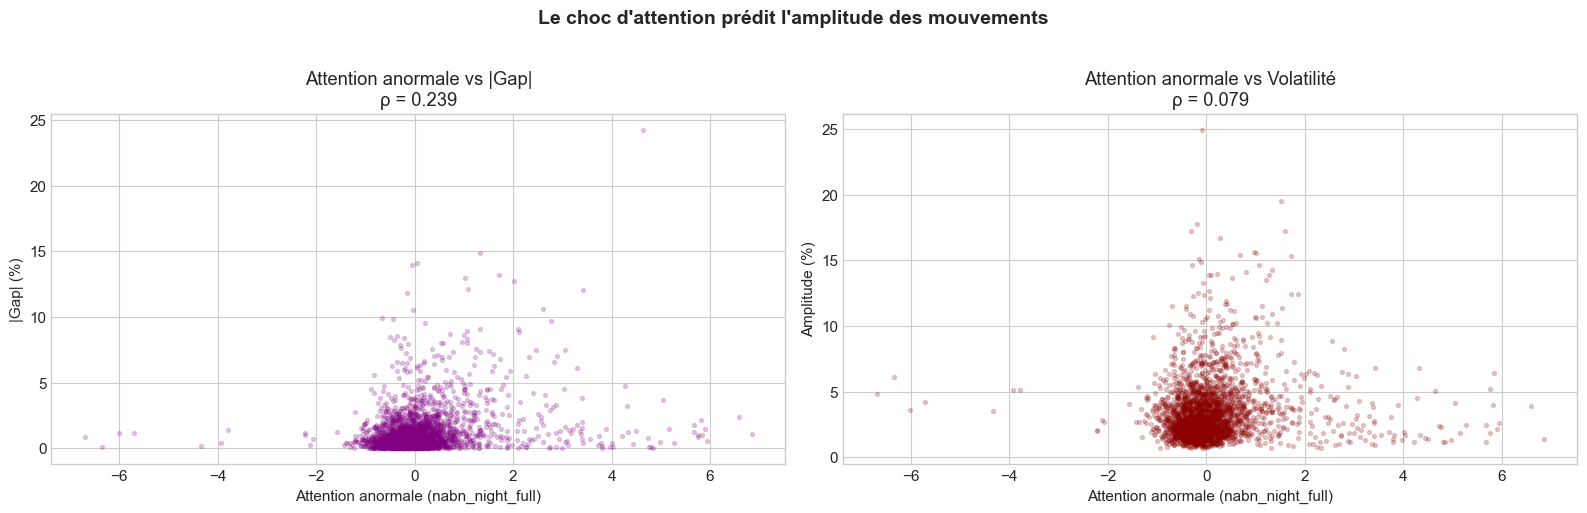

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# nabn vs |gap| (amplitude du gap)
df['abs_gap'] = df['gap'].abs()
axes[0].scatter(df['nabn_night_full'], df['abs_gap'] * 100, alpha=0.2, s=8, color='purple')
rho = df['nabn_night_full'].corr(df['abs_gap'])
axes[0].set_xlabel('Attention anormale (nabn_night_full)')
axes[0].set_ylabel('|Gap| (%)')
axes[0].set_title(f'Attention anormale vs |Gap|\nρ = {rho:.3f}')

# nabn vs volatilité
df['amplitude'] = (df['High'] - df['Low']) / df['Open']
axes[1].scatter(df['nabn_night_full'], df['amplitude'] * 100, alpha=0.2, s=8, color='darkred')
rho2 = df['nabn_night_full'].corr(df['amplitude'])
axes[1].set_xlabel('Attention anormale (nabn_night_full)')
axes[1].set_ylabel('Amplitude (%)')
axes[1].set_title(f'Attention anormale vs Volatilité\nρ = {rho2:.3f}')

plt.suptitle('Le choc d\'attention prédit l\'amplitude des mouvements', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\semy4\OneDrive\Bureau\Fintech_project\docs\EDA_fig9_attention.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print("=" * 70)
print("RÉSUMÉ DE L'EDA — PHASE 5bis (2020-2022)")
print("=" * 70)

for target in ['gap', 'ret_oc', 'ret_cc']:
    valid = df[['mu_night_full', target]].dropna()
    rho, _ = stats.pearsonr(valid['mu_night_full'], valid[target])
    print(f"μ_night_full → {target:8s} : ρ = {rho:+.4f}")

print(f"\nQuintiles (pooled) :")
print(f"  Q1 (très négatif) : {pooled.loc['Q1', 'pct_gap_pos']:.1f}% gaps positifs")
print(f"  Q5 (très positif) : {pooled.loc['Q5', 'pct_gap_pos']:.1f}% gaps positifs")
print(f"  Écart = {pooled.loc['Q5', 'pct_gap_pos'] - pooled.loc['Q1', 'pct_gap_pos']:.1f} points")

valid_seance = df[['mu_night_full', 'ret_oc']].dropna()
rho_seance = valid_seance['mu_night_full'].corr(valid_seance['ret_oc'])
print(f"\nCorrélation séance (ret_oc) : ρ = {rho_seance:.4f}")
print("→ Le sentiment nocturne ne prédit PAS la séance (efficience semi-forte)")

valid_gap = df[['mu_night_full', 'gap']].dropna()
rho_gap = valid_gap['mu_night_full'].corr(valid_gap['gap'])
print(f"\nCorrélation gap (pooled) : ρ = {rho_gap:.4f}")
print("→ Le sentiment nocturne PRÉDIT le gap d'ouverture")

print("\n" + "=" * 70)
print("CONCLUSION : M1 (gap) est le signal principal. M2 (séance) est un résultat honnête.")
print("=" * 70)

RÉSUMÉ DE L'EDA — PHASE 5bis (2020-2022)
μ_night_full → gap      : ρ = +0.1651
μ_night_full → ret_oc   : ρ = -0.0100
μ_night_full → ret_cc   : ρ = +0.0986

Quintiles (pooled) :
  Q1 (très négatif) : 42.2% gaps positifs
  Q5 (très positif) : 70.4% gaps positifs
  Écart = 28.2 points

Corrélation séance (ret_oc) : ρ = -0.0100
→ Le sentiment nocturne ne prédit PAS la séance (efficience semi-forte)

Corrélation gap (pooled) : ρ = 0.1651
→ Le sentiment nocturne PRÉDIT le gap d'ouverture

CONCLUSION : M1 (gap) est le signal principal. M2 (séance) est un résultat honnête.
